# 🃏 Meta-analysis della competizione — Pokémon TCG AI Battle Challenge

Analisi del **card pool ufficiale della competizione** (`doc/pokemon-tcg-ai-battle/EN_Card_Data.csv`,
lo stesso set di carte con cui gli agent costruiscono i mazzi) e dei **mazzi sample** forniti,
con un aggancio opzionale alla **leaderboard Kaggle**.

**Perché serve:** i mazzi degli altri partecipanti non sono pubblici, quindi il modo concreto per
capire il "meta" della competizione è studiare *quali carte sono oggettivamente più forti/efficienti*
nel pool disponibile — informazione diretta per costruire i nostri `deck.csv`.

Indice:
1. Panoramica del card pool
2. Distribuzione per tipo di energia
3. Pokémon più forti (HP, danno, efficienza energetica)
4. Attaccanti più efficienti (danno per energia)
5. Trainer & Energy
6. Analisi dei mazzi sample
7. Leaderboard Kaggle (opzionale) e carte giocate nelle partite


In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
import meta_utils as mu

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "figure.autolayout": True})
PAL = plt.get_cmap("tab10").colors

def save(fig, name):
    fig.savefig(mu.FIG_DIR / f"01_{name}.png", bbox_inches="tight", dpi=130)
    print("salvato:", (mu.FIG_DIR / f"01_{name}.png").name)

cards = mu.load_cards()
uni = mu.cards_unique(cards)
print(f"Righe (mosse): {len(cards)} | Carte uniche: {len(uni)}")
uni.head(3)

Righe (mosse): 2022 | Carte uniche: 1267


,Card ID,Card Name,Expansion,subtype,Rule,hp_num,energy_type,Weakness,Retreat,is_pokemon,is_trainer,is_energy,is_ex,is_mega,is_ace_spec,n_moves,max_damage,best_dmg_per_energy
0,1,Basic {G} Energy,SVE,Basic Energy,NaN,NaN,{G},NaN,NaN,False,False,True,False,False,False,0,NaN,NaN
1,2,Basic {R} Energy,SVE,Basic Energy,NaN,NaN,{R},NaN,NaN,False,False,True,False,False,False,0,NaN,NaN
2,3,Basic {W} Energy,SVE,Basic Energy,NaN,NaN,{W},NaN,NaN,False,False,True,False,False,False,0,NaN,NaN


## 1. Panoramica del card pool
Composizione del pool: categorie di carta, sotto-tipi, carte speciali (ex / Mega / ACE SPEC).

salvato: 01_overview.png


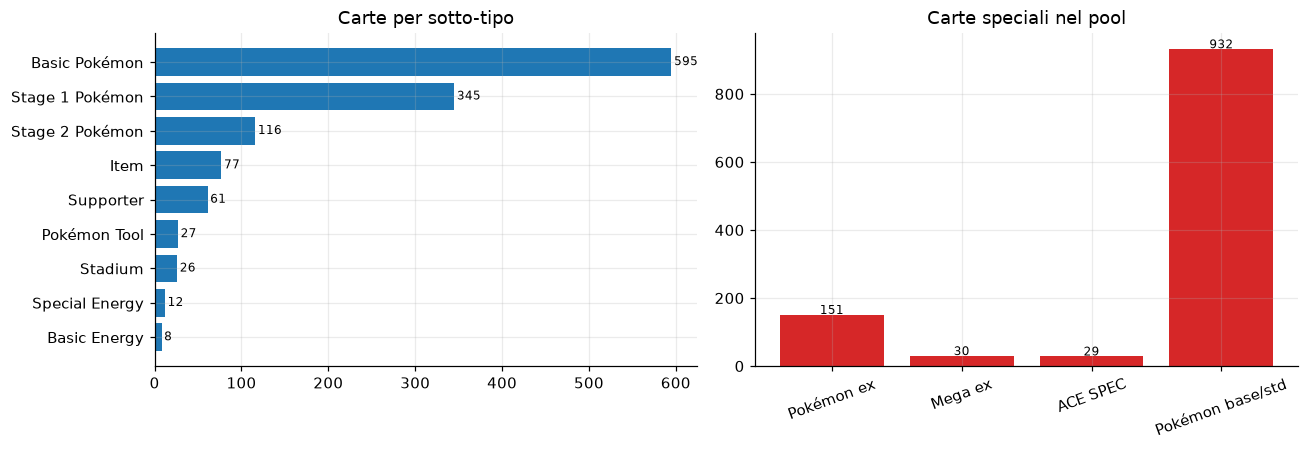

Espansioni presenti: 19


Expansion
DRI    178
MEG    126
ASC    124
TWM     95
SSP     95
PFL     94
JTG     85
WHT     85
BLK     84
POR     81
Name: count, dtype: int64

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sub = uni["subtype"].replace("", "Sconosciuto").value_counts()
ax[0].barh(sub.index[::-1], sub.values[::-1], color=PAL[0])
ax[0].set_title("Carte per sotto-tipo")
for i, v in enumerate(sub.values[::-1]):
    ax[0].text(v + 3, i, str(v), va="center", fontsize=8)

special = pd.Series({
    "Pokémon ex": int(uni["is_ex"].sum()),
    "Mega ex":    int(uni["is_mega"].sum()),
    "ACE SPEC":   int(uni["is_ace_spec"].sum()),
    "Pokémon base/std": int(uni["is_pokemon"].sum() - uni["is_ex"].sum()),
})
ax[1].bar(special.index, special.values, color=PAL[3])
ax[1].set_title("Carte speciali nel pool")
ax[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(special.values):
    ax[1].text(i, v + 2, str(v), ha="center", fontsize=8)
save(fig, "overview"); plt.show()

print("Espansioni presenti:", uni["Expansion"].nunique())
uni["Expansion"].value_counts().head(10)

## 2. Distribuzione per tipo di energia
Quanti Pokémon per ciascun tipo: indica dove il pool è profondo (più scelte) e dove è scarso.

salvato: 01_energy_types.png


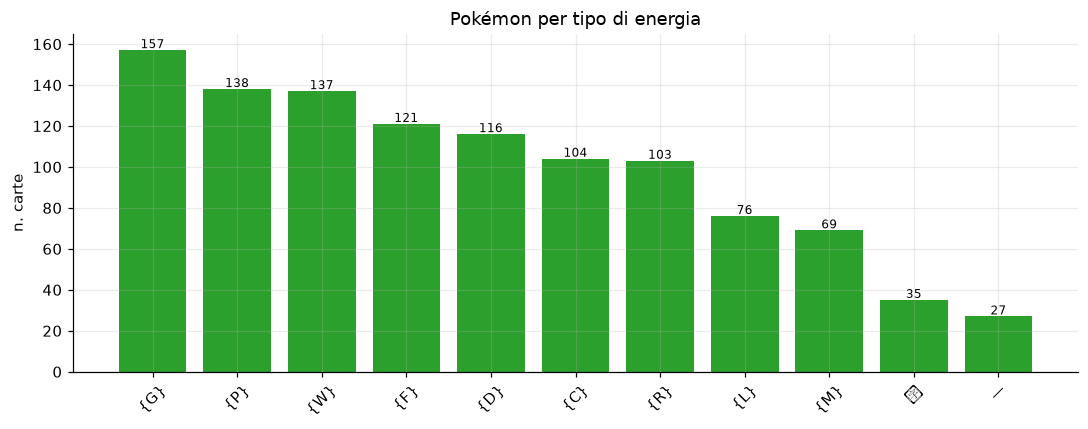

In [3]:
poke = uni[uni["is_pokemon"]].copy()
et = poke["energy_type"].replace("", "—").value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(et.index, et.values, color=PAL[2])
ax.set_title("Pokémon per tipo di energia"); ax.set_ylabel("n. carte")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(et.values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=8)
save(fig, "energy_types"); plt.show()

## 3. Pokémon più forti
Tre lenti complementari:
- **HP** (bulk / sopravvivenza)
- **Danno massimo** (potenza di picco)
- Distribuzione di HP e danno per capire dove si collocano le carte "top".

salvato: 01_hp_damage_dist.png


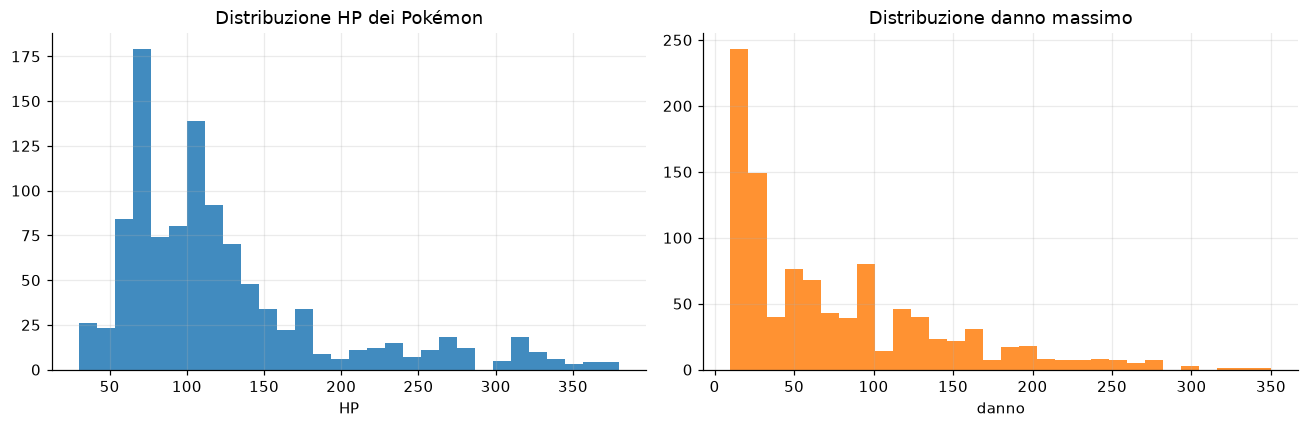

— Top 15 HP —


,Card Name,Expansion,hp_num,energy_type,Rule
0,Mega Emboar ex,ASC,380.0,{R},Mega Pokémon ex
1,Mega Venusaur ex,MEG,380.0,{G},Mega Pokémon ex
2,Mega Feraligatr ex,ASC,370.0,{W},Mega Pokémon ex
3,Mega Dragonite ex,ASC,370.0,竜,Mega Pokémon ex
4,Mega Charizard Y ex,ASC,360.0,{R},Mega Pokémon ex
5,Mega Charizard X ex,PFL,360.0,{R},Mega Pokémon ex
6,Mega Gardevoir ex,MEG,360.0,{P},Mega Pokémon ex
7,Mega Meganium ex,ASC,360.0,{G},Mega Pokémon ex
8,Mega Eelektross ex,ASC,350.0,{L},Mega Pokémon ex
9,Mega Abomasnow ex,MEG,350.0,{W},Mega Pokémon ex


— Top 15 danno massimo —


,Card Name,Expansion,hp_num,max_damage,energy_type,Rule
0,Core Memory,POR,NaN,350.0,,NaN
1,Mega Dragonite ex,ASC,370.0,330.0,竜,Mega Pokémon ex
2,Mega Emboar ex,ASC,380.0,320.0,{R},Mega Pokémon ex
3,Mega Latias ex,MEG,280.0,300.0,竜,Mega Pokémon ex
4,Salamence ex,JTG,320.0,300.0,竜,Pokémon ex
5,Pikachu ex,SSP,200.0,300.0,{L},Pokémon ex
6,Jolteon ex,PRE,260.0,280.0,{L},Pokémon ex
7,Ceruledge ex,SSP,270.0,280.0,{R},Pokémon ex
8,Mega Camerupt ex,MEG,340.0,280.0,{R},Mega Pokémon ex
9,Vaporeon ex,PRE,280.0,280.0,{W},Pokémon ex


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(poke["hp_num"].dropna(), bins=30, color=PAL[0], alpha=.85)
ax[0].set_title("Distribuzione HP dei Pokémon"); ax[0].set_xlabel("HP")
dmg = poke["max_damage"].dropna()
ax[1].hist(dmg[dmg > 0], bins=30, color=PAL[1], alpha=.85)
ax[1].set_title("Distribuzione danno massimo"); ax[1].set_xlabel("danno")
save(fig, "hp_damage_dist"); plt.show()

print("— Top 15 HP —")
top_hp = poke.sort_values("hp_num", ascending=False).head(15)[["Card Name","Expansion","hp_num","energy_type","Rule"]]
display(top_hp.reset_index(drop=True))
print("— Top 15 danno massimo —")
display(poke.sort_values("max_damage", ascending=False).head(15)[["Card Name","Expansion","hp_num","max_damage","energy_type","Rule"]].reset_index(drop=True))

## 4. Attaccanti più efficienti (danno per energia)
Il danno grezzo non basta: conta quante energie servono. `dmg_per_energy` = danno della mossa /
numero di simboli di energia nel costo. Le carte in alto a sinistra dello scatter (tanto danno,
poche energie) sono le più "tempo-efficienti".

salvato: 01_damage_efficiency.png


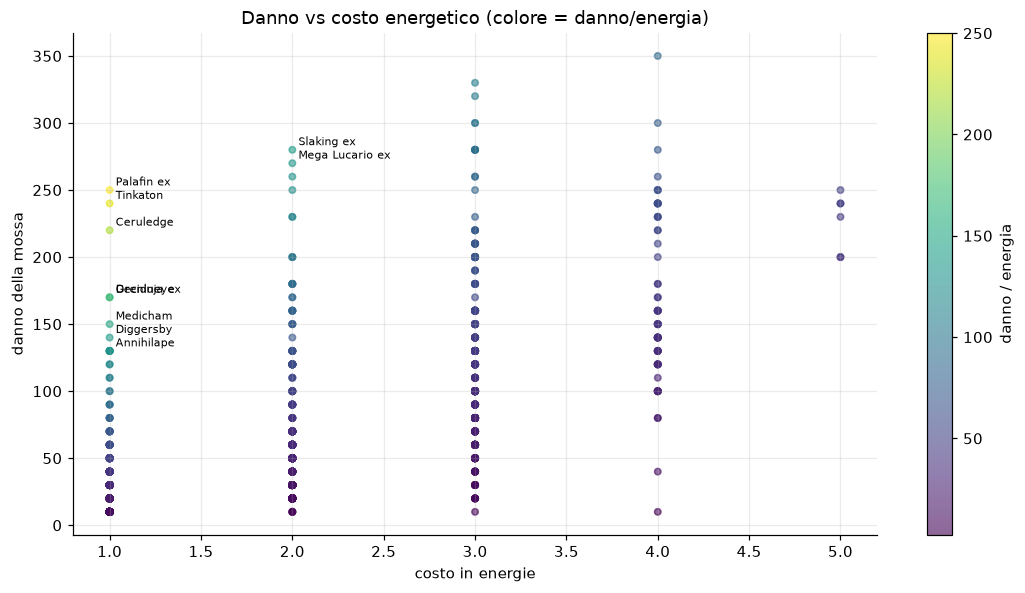

— Top 15 danno/energia (mosse a costo >= 1) —


,Card Name,Move Name,Cost,damage_num,energy_cost,dmg_per_energy,Rule
0,Palafin ex,Giga Impact,{W},250.0,1.0,250.0,Pokémon ex
1,Tinkaton,Windup Swing,{M},240.0,1.0,240.0,NaN
2,Ceruledge,Infernal Slash,{R},220.0,1.0,220.0,NaN
3,Decidueye,Power Shot,{G},170.0,1.0,170.0,NaN
4,Greninja ex,Shinobi Blade,{W},170.0,1.0,170.0,Pokémon ex
5,Medicham,Seventh Kick,{F},150.0,1.0,150.0,NaN
6,Slaking ex,Great Swing,●●,280.0,2.0,140.0,Pokémon ex
7,Diggersby,Earthquake,●,140.0,1.0,140.0,NaN
8,Mega Lucario ex,Mega Brave,{F}{F},270.0,2.0,135.0,Mega Pokémon ex
9,Annihilape,Tantrum,{F},130.0,1.0,130.0,NaN


In [5]:
mv = cards[cards["is_pokemon"] & cards["damage_num"].notna() & (cards["energy_cost"] > 0)].copy()
fig, ax = plt.subplots(figsize=(10, 5.5))
sc = ax.scatter(mv["energy_cost"], mv["damage_num"], s=18,
                c=mv["dmg_per_energy"], cmap="viridis", alpha=.6)
ax.set_xlabel("costo in energie"); ax.set_ylabel("danno della mossa")
ax.set_title("Danno vs costo energetico (colore = danno/energia)")
plt.colorbar(sc, ax=ax, label="danno / energia")
# etichetta le più efficienti
best = mv.sort_values("dmg_per_energy", ascending=False).drop_duplicates("Card ID").head(10)
for _, r in best.iterrows():
    ax.annotate(r["Card Name"], (r["energy_cost"], r["damage_num"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points")
save(fig, "damage_efficiency"); plt.show()

print("— Top 15 danno/energia (mosse a costo >= 1) —")
best15 = mv.sort_values("dmg_per_energy", ascending=False).drop_duplicates("Card ID").head(15)
display(best15[["Card Name","Move Name","Cost","damage_num","energy_cost","dmg_per_energy","Rule"]].reset_index(drop=True))

## 5. Trainer & Energy
Supporter, Item, Tool, Stadium ed energie speciali disponibili: la 'spina dorsale' di consistenza di ogni mazzo.

salvato: 01_trainers.png


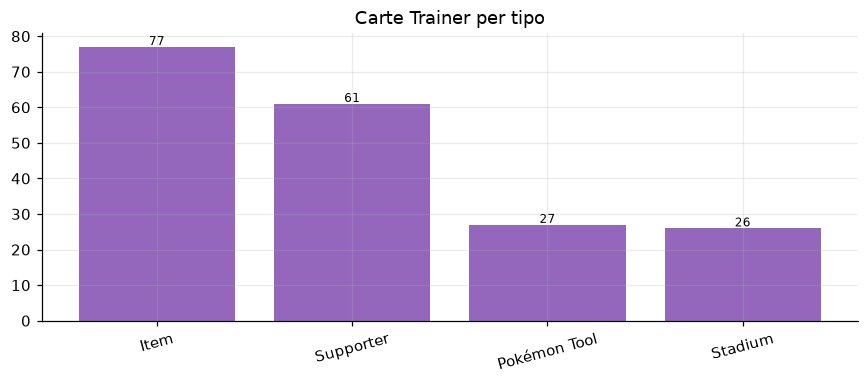

Supporter disponibili: 61


,Card Name,Expansion
0,Billy & O'Nare,JTG
1,Boss’s Orders,PAL
2,Perrin,TWM
3,Lana’s Aid,TWM
4,Explorer’s Guidance,TEF
5,Eri,TEF
6,Morty’s Conviction,TEF
7,Ciphermaniac’s Codebreaking,TEF
8,Salvatore,TEF
9,Bianca’s Devotion,TEF


In [6]:
trainers = uni[uni["is_trainer"]]
fig, ax = plt.subplots(figsize=(8, 3.6))
tc = trainers["subtype"].value_counts()
ax.bar(tc.index, tc.values, color=PAL[4])
ax.set_title("Carte Trainer per tipo"); ax.tick_params(axis="x", rotation=15)
for i, v in enumerate(tc.values):
    ax.text(i, v + .5, str(v), ha="center", fontsize=8)
save(fig, "trainers"); plt.show()

print("Supporter disponibili:", int((trainers["subtype"]=="Supporter").sum()))
display(trainers[trainers["subtype"]=="Supporter"][["Card Name","Expansion"]].head(20).reset_index(drop=True))

## 6. Analisi dei mazzi sample
Carichiamo i `deck.csv` disponibili (il `sample_submission` ufficiale e gli agent locali) e ne
analizziamo la composizione: bilanciamento Pokémon / Trainer / Energy e curva dei costi.

,deck,n_carte,Pokémon,Trainer,Energy,ex/Mega,carte_uniche
0,sample_submission,60,11,15,35,4,9
1,example_random,60,11,15,35,4,9


salvato: 01_sample_decks.png


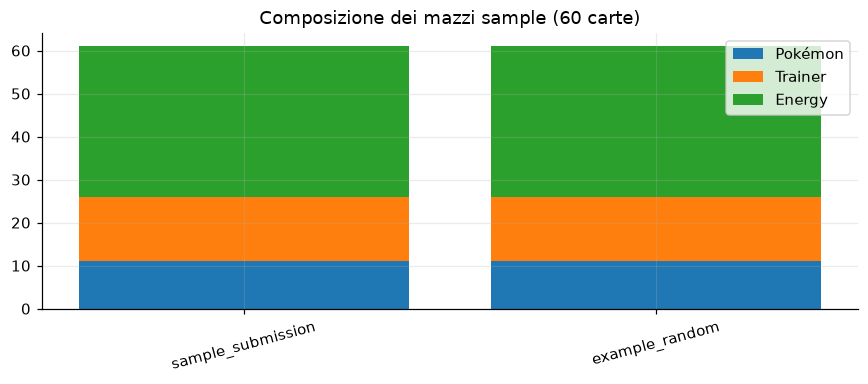

In [7]:
def load_deck(path):
    ids = [int(x) for x in Path(path).read_text().split() if x.strip().isdigit()]
    return ids

deck_paths = {"sample_submission": mu.SAMPLE_SUBMISSION_DECK}
for d in sorted(mu.AGENTS_DIR.glob("*/deck.csv")):
    deck_paths[d.parent.name] = d

id2row = uni.set_index("Card ID")
rows = []
for name, p in deck_paths.items():
    if not Path(p).exists():
        continue
    ids = load_deck(p)
    sub = id2row.reindex(ids)
    rows.append({
        "deck": name, "n_carte": len(ids),
        "Pokémon": int(sub["is_pokemon"].sum()),
        "Trainer": int(sub["is_trainer"].sum()),
        "Energy": int(sub["is_energy"].sum()),
        "ex/Mega": int((sub["is_ex"] | sub["is_mega"]).sum()),
        "carte_uniche": len(set(ids)),
    })
deck_df = pd.DataFrame(rows)
display(deck_df)

# composizione stacked
if len(deck_df):
    fig, ax = plt.subplots(figsize=(8, 3.6))
    bottom = np.zeros(len(deck_df))
    for i, col in enumerate(["Pokémon","Trainer","Energy"]):
        ax.bar(deck_df["deck"], deck_df[col], bottom=bottom, label=col, color=PAL[i])
        bottom += deck_df[col].values
    ax.set_title("Composizione dei mazzi sample (60 carte)"); ax.legend()
    ax.tick_params(axis="x", rotation=15)
    save(fig, "sample_decks"); plt.show()

In [8]:
# Carte più incluse nel/i mazzo/i sample (conteggio copie)
from collections import Counter
cnt = Counter()
for name, p in deck_paths.items():
    if Path(p).exists():
        for cid in load_deck(p):
            cnt[cid] += 1
top_cards = (pd.DataFrame([(id2row["Card Name"].get(cid, f"ID {cid}"), n) for cid, n in cnt.most_common(20)],
                          columns=["Carta", "copie_totali"]))
print("Carte più presenti nei mazzi sample disponibili:")
display(top_cards)

Carte più presenti nei mazzi sample disponibili:


,Carta,copie_totali
0,Basic {W} Energy,70
1,Snover,8
2,Mega Abomasnow ex,8
3,Mega Signal,8
4,Lillie's Determination,8
5,Waitress,8
6,Kyogre,4
7,Cyrano,4
8,Maximum Belt,2


## 7. Leaderboard Kaggle e carte giocate nelle partite *(opzionale)*

La leaderboard pubblica mostra il **ranking degli agent**. Per scaricarla serve il pacchetto
`kaggle` e un token in `~/.kaggle/kaggle.json` (Account Kaggle → *Create New API Token*).
Senza credenziali la cella non fallisce: stampa solo un avviso.

> **Carte giocate nelle partite** — la competizione è a simulazione: dai replay/episodi delle
> partite si possono, in linea di principio, contare le carte effettivamente giocate. L'accesso ai
> replay passa dalla stessa Kaggle API (episodi della simulazione) e richiede le credenziali +
> l'ID numerico della competizione. La funzione qui sotto scarica la leaderboard; l'estrazione
> delle carte dai replay è predisposta come passo successivo una volta disponibili le credenziali,
> perché lo schema esatto del replay va letto da un episodio reale prima di parsarlo in modo affidabile.

In [9]:
lb = mu.kaggle_leaderboard()
if lb is not None:
    display(lb.head(25))
    lb.to_csv(mu.DATA_DIR / "kaggle_leaderboard.csv", index=False)
    print("Salvato:", (mu.DATA_DIR / "kaggle_leaderboard.csv"))
else:
    print("Leaderboard non caricata (credenziali Kaggle assenti). Il resto del notebook è comunque completo.")

[meta_utils] leaderboard non disponibile (ModuleNotFoundError: No module named 'kaggle').
  -> installa 'kaggle' e metti kaggle.json in ~/.kaggle/ per abilitarla.
Leaderboard non caricata (credenziali Kaggle assenti). Il resto del notebook è comunque completo.


### Esporta i risultati
Salviamo le tabelle chiave in `output/data/` per riuso in altri script.

In [10]:
uni.sort_values("max_damage", ascending=False).head(50).to_csv(mu.DATA_DIR / "top_damage_cards.csv", index=False)
best15.to_csv(mu.DATA_DIR / "top_efficiency_cards.csv", index=False) if 'best15' in globals() else None
deck_df.to_csv(mu.DATA_DIR / "sample_decks_summary.csv", index=False) if 'deck_df' in globals() else None
print("Export completato in", mu.DATA_DIR)

Export completato in C:\Users\mbasc\workspaces\Pokemon-AI-Battle\meta_analysis\output\data
